# Avaliação em lote — Modelos de Segmentação Fotovoltaica

Carrega cada combinação **cabeça de segmentação × backbone** já treinada (arquivos `.keras`
salvos no Drive pelo `train_fotovoltaica_colab_v2.ipynb`), roda inferência sobre o **split de
teste** e calcula acurácia, precisão, recall, F1-score (Dice) e IoU — salvando tudo em uma
tabela CSV única no Drive.

Reaproveita, sem alterar a lógica, os seguintes blocos de `train_fotovoltaica_colab_v2.ipynb`:
autenticação/montagem do Drive, verificação de GPU, imports, upload/import do
`segmentation_model_factory.py`, as funções de custom loss/métrica registradas na célula 23
(necessárias para carregar os `.keras` salvos) e o pipeline de dados TFRecord (parse + dataset).

---
**Antes de começar:** em `Ambiente de execução → Alterar tipo de ambiente de execução`,
selecione **GPU**.

## 1. Autenticação e montagem do Drive

In [1]:
## célula 1
from google.colab import auth
auth.authenticate_user()
print('Autenticado com sucesso!')


Autenticado com sucesso!


In [29]:
## célula 2
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


## 2. Verificação de GPU

In [3]:
## célula 3
import tensorflow as tf
print(f'TensorFlow versão: {tf.__version__}')

device_name = tf.test.gpu_device_name()
if device_name == '/device:GPU:0':
    DEVICE = 'gpu'
    print(f'GPU encontrada em: {device_name}')
    for g in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(g, True)
else:
    DEVICE = 'cpu'
    print('[AVISO] Nenhuma GPU encontrada — avaliação será mais lenta em CPU.')


TensorFlow versão: 2.20.0
GPU encontrada em: /device:GPU:0


## 3. Imports

In [14]:
## célula 4
import os
import re
import gc
import glob
import time
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
import keras.ops as kops

print('Imports OK')


Imports OK


## 4. Upload / import do `segmentation_model_factory.py`

Mesmo arquivo usado no treino — precisa estar em `path_root_scripts` no Drive
(ver `train_fotovoltaica_colab_v2.ipynb`, célula 10).

In [5]:
## célula 5
path_root_scripts = '/content/drive/MyDrive/DL_fotovoltaica'
import sys
sys.path.insert(0, path_root_scripts)
import importlib
import segmentation_model_factory
importlib.reload(segmentation_model_factory)

from segmentation_model_factory import ResizeLike

print('segmentation_model_factory importada (usamos apenas ResizeLike — a arquitetura')
print('de cada modelo já está salva dentro do .keras, não precisamos reconstruí-la).')


segmentation_model_factory importada (usamos apenas ResizeLike — a arquitetura
de cada modelo já está salva dentro do .keras, não precisamos reconstruí-la).


## 5. Configuração

Ajuste os caminhos e as listas de cabeças/backbones a avaliar. As listas abaixo já refletem
o pedido original: 4 cabeças × 7 valores de backbone (incluindo `None` = sem backbone,
arquitetura vanilla) = até 28 combinações possíveis — o script detecta sozinho quais
realmente têm um `.keras` salvo no Drive e ignora o resto, sem quebrar.

In [26]:
## célula 6 — AJUSTE AQUI
# Pasta com subpastas train/ val/ test/ contendo os *.tfrecord.gz (mesma do treino)
DATASET_ROOT_DS = '/content/drive/MyDrive/DS_FV_tfs_scaled_v3'

# Pasta onde os modelos .keras treinados estão salvos (mesma do treino: OUTPUT_MODEL_DIR)
OUTPUT_MODEL_DIR = os.path.join(path_root_scripts, 'models_2026')

# Pasta onde a tabela de resultados (CSV) e o gráfico comparativo serão salvos
RESULTS_DIR = os.path.join(path_root_scripts, 'avaliacao_modelos')
os.makedirs(RESULTS_DIR, exist_ok=True)

# Combinações a avaliar — o script busca no Drive só as que existem
SEGMENTATION_HEADS = ['unet', 'deeplabv3plus', 'pspnet', 'fpn']
BACKBONE_NET = [None, 'resnet50', 'resnet101', 'resnet152',
                'xception', 'efficientnetb7', 'inceptionresnet']

# Todos os checkpoints deste projeto (geração atual, 5 bandas) foram treinados com
# USE_ATTENTION=True (Focus <cabeça>) — não é possível recuperar esse valor a partir do
# nome do arquivo .keras, por isso é fixado aqui. Ajuste manualmente se algum modelo da
# sua pasta foi treinado com USE_ATTENTION=False.
USE_ATTENTION_ASSUMIDO = True

# Bandas e patches — devem ser IDÊNTICOS aos usados na exportação dos TFRecords de teste
BANDS_LIST     = ['blue', 'green', 'red', 'pvi', 'pvpi']
LABEL_KEY      = 'label'
FEATURES_KEYS  = BANDS_LIST + [LABEL_KEY]
PATCH_SIZE     = 256
RAW_PATCH_SIZE = 257     # saída GEE: kernel rectangle(128,128) = 257×257
INPUT_SHAPE    = (PATCH_SIZE, PATCH_SIZE, len(BANDS_LIST))
NORM_FACTOR    = 10000.0 # valores Int16 em [0, 10000]

# Batch pequeno de propósito: avaliação não faz backprop, então não há motivo para usar
# um batch grande, e cabeças como FPN têm tensores internos muito maiores por amostra
# do que U-Net/DeepLabV3+/PSPNet (fundem a pirâmide de volta em resolução alta) — em
# lote de 24-25 modelos na mesma sessão, a memória CUDA já alocada por modelos
# anteriores não é devolvida pelo TensorFlow entre um load_model() e outro, então o
# batch precisa caber mesmo com a GPU parcialmente ocupada pelo histórico da sessão.
EVAL_BATCH_SIZE = 8
# Se ainda assim um modelo específico estourar memória, avaliar_modelo() tenta de novo
# sozinho com um batch menor (ver MAX_TENTATIVAS_OOM na célula 11) antes de desistir.
MAX_TENTATIVAS_OOM = 3

# Limiar único usado para binarizar a predição em TODAS as métricas de limiar
# (precision, recall, accuracy, IoU) — mantém as métricas comparáveis entre si.
# Os valores usados em pontos distintos do notebook de treino divergem (0.75 na métrica
# de IoU do treino, 0.35 na visualização de predições) — aqui fixamos um único valor.
EVAL_THRESHOLD = 0.5

TIMESTAMP_RUN = datetime.datetime.now().strftime('%Y%m%d_%H%M')

print(f'Dataset root  : {DATASET_ROOT_DS}')
print(f'Modelos em    : {OUTPUT_MODEL_DIR}')
print(f'Resultados em : {RESULTS_DIR}')
print(f'Cabeças       : {SEGMENTATION_HEADS}')
print(f'Backbones     : {BACKBONE_NET}')
print(f'Combinações máx. possíveis: {len(SEGMENTATION_HEADS) * len(BACKBONE_NET)}')


Dataset root  : /content/drive/MyDrive/DS_FV_tfs_scaled_v3
Modelos em    : /content/drive/MyDrive/DL_fotovoltaica/models_2026
Resultados em : /content/drive/MyDrive/DL_fotovoltaica/avaliacao_modelos
Cabeças       : ['unet', 'deeplabv3plus', 'pspnet', 'fpn']
Backbones     : [None, 'resnet50', 'resnet101', 'resnet152', 'xception', 'efficientnetb7', 'inceptionresnet']
Combinações máx. possíveis: 28


## 6. Custom losses e métricas (necessárias para carregar os `.keras`)

Reprodução **exata** das funções definidas na célula 23 de `train_fotovoltaica_colab_v2.ipynb`.
Todos os checkpoints atuais foram compilados com `focal_tversky_boundary_loss` e a métrica
`dice_coef` registrada sob o pacote `'Custom'` — sem redefinir essas funções aqui, com os
mesmos nomes/pacotes, o `load_model()` falha ao tentar desserializar o `.keras`.

In [7]:
## célula 7
@keras.utils.register_keras_serializable(package='Custom')
def dice_coef(y_true, y_pred, smooth=1e-6):
    """F1-Score diferenciável para segmentação binária (Dice == F1 neste contexto)."""
    y_true_f = kops.reshape(kops.cast(y_true, 'float32'), [-1])
    y_pred_f = kops.reshape(kops.cast(y_pred, 'float32'), [-1])
    intersection = kops.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (kops.sum(y_true_f) + kops.sum(y_pred_f) + smooth)


@keras.utils.register_keras_serializable(package='Custom')
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


@keras.utils.register_keras_serializable(package='RemoteSensing')
def focal_tversky_loss(y_true, y_pred, alpha=0.3, beta=0.7, gamma=1.25, smooth=1e-6):
    y_true = kops.cast(y_true, 'float32')
    y_pred = kops.cast(y_pred, 'float32')
    y_true_f = kops.reshape(y_true, [-1])
    y_pred_f = kops.reshape(y_pred, [-1])
    tp = kops.sum(y_true_f * y_pred_f)
    fp = kops.sum((1 - y_true_f) * y_pred_f)
    fn = kops.sum(y_true_f * (1 - y_pred_f))
    tversky_index = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return kops.power((1 - tversky_index), gamma)


@keras.utils.register_keras_serializable(package='RemoteSensing')
def boundary_loss(y_true, y_pred, smooth=1e-6):
    y_true = kops.cast(y_true, 'float32')
    y_pred = kops.cast(y_pred, 'float32')
    dilated  =  tf.nn.max_pool2d( y_true, ksize=3, strides=1, padding='SAME')
    eroded   = -tf.nn.max_pool2d(-y_true, ksize=3, strides=1, padding='SAME')
    boundary = dilated - eroded
    p   = kops.clip(y_pred, 1e-7, 1.0 - 1e-7)
    bce = -(y_true * kops.log(p) + (1 - y_true) * kops.log(1 - p))
    return kops.sum(bce * boundary) / (kops.sum(boundary) + smooth)


@keras.utils.register_keras_serializable(package='RemoteSensing')
def focal_tversky_boundary_loss(y_true, y_pred, alpha=0.3, beta=0.7, gamma=1.25,
                                 boundary_weight=0.25, smooth=1e-6):
    tversky  = focal_tversky_loss(y_true, y_pred, alpha=alpha, beta=beta,
                                   gamma=gamma, smooth=smooth)
    boundary = boundary_loss(y_true, y_pred, smooth=smooth)
    return tversky + boundary_weight * boundary


CUSTOM_OBJECTS = {
    'dice_coef': dice_coef,
    'dice_loss': dice_loss,
    'focal_tversky_loss': focal_tversky_loss,
    'boundary_loss': boundary_loss,
    'focal_tversky_boundary_loss': focal_tversky_boundary_loss,
    'ResizeLike': ResizeLike,
}
print('Custom objects prontos para load_model():', list(CUSTOM_OBJECTS.keys()))


Custom objects prontos para load_model(): ['dice_coef', 'dice_loss', 'focal_tversky_loss', 'boundary_loss', 'focal_tversky_boundary_loss', 'ResizeLike']


## 7. Pipeline de dados (TFRecord) — split de teste

Reaproveita, sem alterar, `parse_tfrecord` / `to_model_tuple` / `removeNan` / `build_dataset`
da célula 16 do notebook de treino. Sem augmentation — é avaliação, não treino.

In [18]:
## célula 8
FEATURE_DESCRIPTION = {
    key: tf.io.FixedLenFeature([RAW_PATCH_SIZE, RAW_PATCH_SIZE], tf.float32)
    for key in FEATURES_KEYS
}

def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, FEATURE_DESCRIPTION)
    return {
        key: tf.slice(parsed[key], [0, 0], [PATCH_SIZE, PATCH_SIZE])
        for key in FEATURES_KEYS
    }


def to_model_tuple(inputs):
    img   = tf.stack([inputs[b] for b in BANDS_LIST], axis=-1)
    label = tf.expand_dims(inputs[LABEL_KEY], axis=-1)
    img   = tf.cast(img,   tf.float32) / NORM_FACTOR
    label = tf.cast(label, tf.float32)
    label = tf.clip_by_value(label, 0.0, 1.0)
    return img, label


def removeNan(image, label):
    image = tf.where(tf.math.is_nan(image), tf.zeros_like(image), image)
    label = tf.where(tf.math.is_nan(label), tf.zeros_like(label), label)
    return image, label


def build_dataset(split, batch_size):
    pattern = os.path.join(DATASET_ROOT_DS, split, '*.tfrecord.gz')
    files   = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f'Nenhum TFRecord em: {pattern}')
    print(f'  [{split:5s}] {len(files)} arquivo(s)')

    ds = tf.data.TFRecordDataset(files, compression_type='GZIP',
                                 num_parallel_reads=tf.data.AUTOTUNE)
    ds = ds.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(to_model_tuple, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(removeNan,      num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


print('Pipeline de dados definido.')


Pipeline de dados definido.


In [19]:
## célula 9
# Mantemos test_ds como variável global (usada pela célula 9A de visualização, e como
# checagem fail-fast de que o split de teste existe e é legível antes do loop de
# 20-25 avaliações). O batch aqui é só para essa checagem/visualização — cada chamada
# de avaliar_modelo() (célula 11) constrói seu PRÓPRIO dataset internamente, com o
# batch_size da tentativa atual, que pode ser menor em caso de retry por falta de
# memória (ver MAX_TENTATIVAS_OOM na célula 6).
test_ds = build_dataset('test', EVAL_BATCH_SIZE)
for _batch_img, _batch_lbl in test_ds.take(1):
    print(f'Split de teste OK — shape de um batch: imagens={_batch_img.shape}  labels={_batch_lbl.shape}')


  [test ] 128 arquivo(s)
Dataset de teste construído (reutilizado em todas as avaliações abaixo).


## 7A. Visualizar amostras do dataset

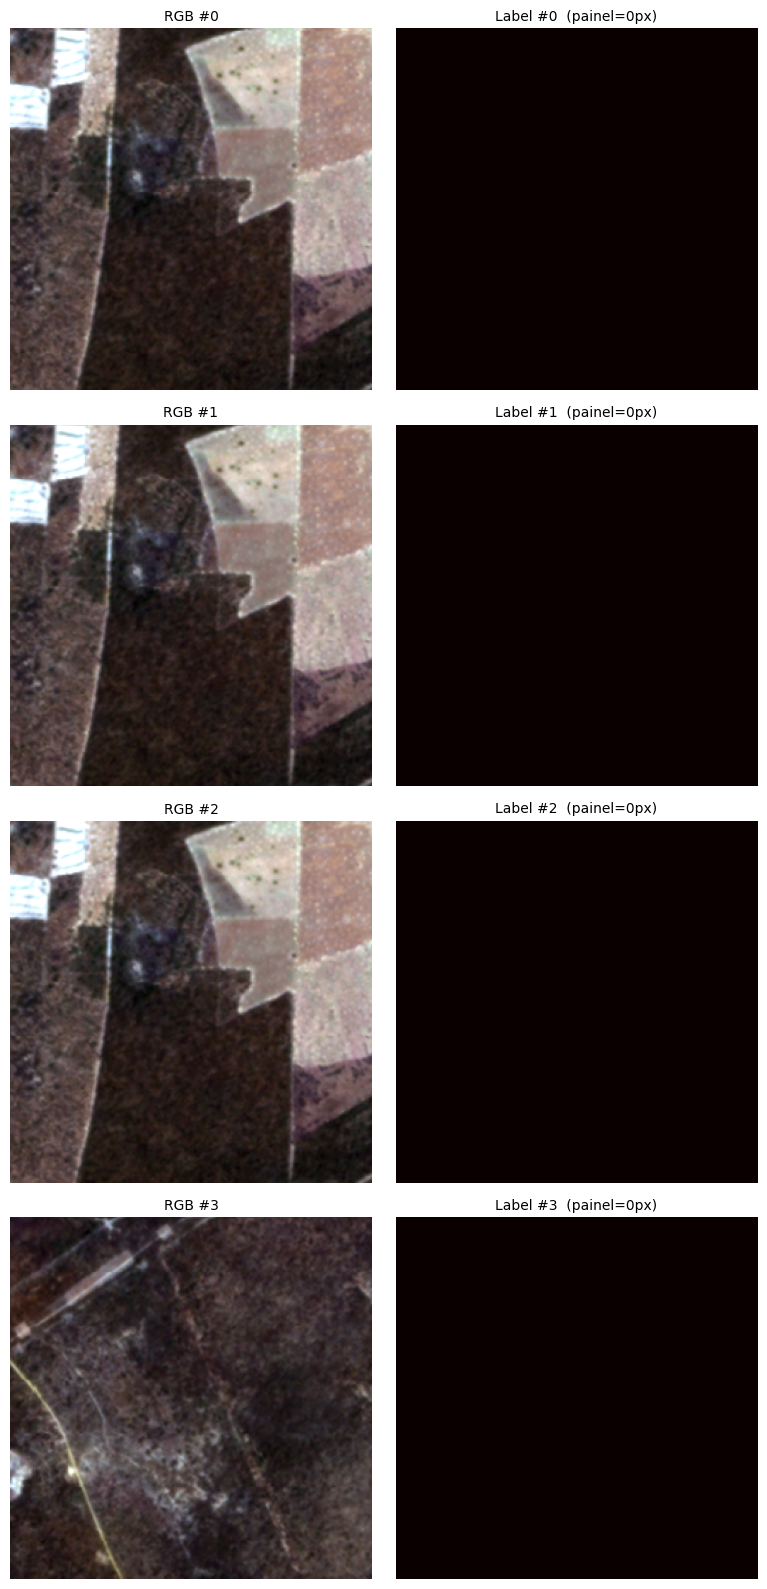

In [25]:
## célula no. 9A
def convertInt16_to_Int8(arr):
    vmin, vmax = arr.min(), arr.max()
    return (((arr - vmin) / (vmax - vmin + 1e-8)) * 255).astype(np.uint8)

def show_batch(dataset, n_samples=4, saber_max=False):
    batch_img, batch_lbl = next(iter(dataset))
    fig, axes = plt.subplots(n_samples, 2, figsize=(8, n_samples * 4))
    for i in range(n_samples):
        img = batch_img[i].numpy() * NORM_FACTOR  # volta para escala original
        lbl = batch_lbl[i, :, :, 0].numpy()

        r = convertInt16_to_Int8(img[:, :, 2])   # red
        g = convertInt16_to_Int8(img[:, :, 1])   # green
        b = convertInt16_to_Int8(img[:, :, 0])   # blue
        rgb = np.stack([r, g, b], axis=-1)

        axes[i, 0].imshow(rgb, vmin=0, vmax=255)
        axes[i, 0].set_title(f'RGB #{i}', fontsize=10)
        axes[i, 0].axis('off')

        axes[i, 1].imshow(lbl, cmap='hot', vmin=0, vmax=1)
        axes[i, 1].set_title(f'Label #{i}  (painel={lbl.sum():.0f}px)', fontsize=10)
        axes[i, 1].axis('off')

        if saber_max:
            # Se 'img' for um tensor do TensorFlow:
            maximos = tf.reduce_max(img, axis=(0, 1)).numpy()

            # Se 'img' já for um array NumPy:
            maximos = np.max(img, axis=(0, 1))

            for i, banda in enumerate(BANDS_LIST):
                print(f"Máximo da banda {banda}: {maximos[i]:.4f}")

    plt.tight_layout()
    plt.show()


show_batch(test_ds, n_samples=4, saber_max=False)

## 8. Descoberta dos modelos treinados no Drive

In [30]:
## célula 10
_TIMESTAMP_RE = re.compile(r'_(\d{8}_\d{4})_v3\.keras$')

def _rotulo_backbone(backbone):
    return 'None' if backbone is None else backbone


def descobrir_modelos(output_model_dir, heads, backbones, use_attention_assumido):
    """
    Para cada combinação (head, backbone), busca todos os .keras que casam com
    best_5L_{head}_{backbone}_*_v3.keras — pode haver mais de uma execução por
    combinação (ex.: reruns); todas são incluídas, cada uma com seu timestamp.
    Combinações sem nenhum arquivo encontrado são reportadas, não silenciadas.
    """
    encontrados, faltantes = [], []
    for head in heads:
        for backbone in backbones:
            bb_label = _rotulo_backbone(backbone)
            pattern = os.path.join(
                output_model_dir, f'best_5L_{head}_{bb_label}_*_v3.keras'
            )
            matches = sorted(glob.glob(pattern))
            if not matches:
                faltantes.append((head, bb_label))
                continue
            for path in matches:
                m = _TIMESTAMP_RE.search(path)
                timestamp = m.group(1) if m else 'desconhecido'
                encontrados.append({
                    'segmentation_head': head,
                    'backbone_name': bb_label,
                    'use_attention': use_attention_assumido,
                    'timestamp': timestamp,
                    'model_path': path,
                })
    return encontrados, faltantes


modelos_encontrados, combinacoes_faltantes = descobrir_modelos(
    OUTPUT_MODEL_DIR, SEGMENTATION_HEADS, BACKBONE_NET, USE_ATTENTION_ASSUMIDO
)

print(f'{len(modelos_encontrados)} checkpoint(s) encontrado(s) no Drive.')
if combinacoes_faltantes:
    print(f'\n{len(combinacoes_faltantes)} combinação(ões) sem checkpoint salvo (ignoradas):')
    for head, bb in combinacoes_faltantes:
        print(f'  - {head} + {bb}')


25 checkpoint(s) encontrado(s) no Drive.

4 combinação(ões) sem checkpoint salvo (ignoradas):
  - deeplabv3plus + resnet101
  - deeplabv3plus + resnet152
  - pspnet + resnet101
  - fpn + resnet101


## 9. Avaliação — função por modelo

In [31]:
## célula 11
def avaliar_modelo(model_info, batch_size, custom_objects, eval_threshold,
                    max_tentativas_oom=MAX_TENTATIVAS_OOM, max_tentativas_leitura=2):
    """
    Carrega um checkpoint, recompila só para fins de avaliação (métricas amplas,
    não as usadas no treino) e roda model.evaluate() sobre o split de teste inteiro.
    Nunca propaga uma exceção — um checkpoint problemático vira uma linha com
    status='erro', sem interromper a avaliação dos demais.

    Duas resiliências, adicionadas depois de observar as duas falhas reais em produção:

    1. RESOURCE_EXHAUSTED (GPU sem memória) — algumas cabeças (ex.: FPN) têm tensores
       internos muito maiores por amostra que as demais, e a memória CUDA já alocada
       por modelos anteriores na mesma sessão não é devolvida pelo TensorFlow entre um
       load_model() e outro. Em vez de desistir, tenta de novo com um batch 4x menor
       (até o piso de 1) até `max_tentativas_oom` vezes.
    2. Erro transitório de leitura no Drive (ex.: "File not found" logo após o arquivo
       ter sido encontrado pelo glob em descobrir_modelos) — comportamento conhecido do
       Google Drive montado via FUSE no Colab. Tenta ler de novo, com uma pequena espera,
       antes de desistir.
    """
    linha = dict(model_info)
    linha_erro_base = {
        'batch_size_usado': None, 'n_params': None, 'test_loss': None,
        'accuracy': None, 'precision': None, 'recall': None,
        'f1_score_dice': None, 'iou': None,
    }
    t0 = time.time()
    batch_tentativa = batch_size

    for tentativa in range(1, max_tentativas_oom + 1):
        model = None
        try:
            # --- carregar, com retry curto para flakiness do Drive ---
            for tentativa_leitura in range(1, max_tentativas_leitura + 1):
                try:
                    model = keras.models.load_model(model_info['model_path'],
                                                     custom_objects=custom_objects)
                    break
                except Exception as exc_load:
                    if tentativa_leitura == max_tentativas_leitura:
                        raise
                    print(f"    [aviso] falha ao ler do Drive (tentativa {tentativa_leitura}), "
                          f"retentando em 5s: {exc_load}")
                    time.sleep(5)

            model.compile(
                loss=focal_tversky_boundary_loss,
                metrics=[
                    keras.metrics.BinaryAccuracy(threshold=eval_threshold, name='accuracy'),
                    keras.metrics.Precision(thresholds=eval_threshold, name='precision'),
                    keras.metrics.Recall(thresholds=eval_threshold, name='recall'),
                    dice_coef,  # F1-Score (Dice) — ver célula 7
                    keras.metrics.BinaryIoU(target_class_ids=[1], threshold=eval_threshold, name='iou'),
                ],
            )
            n_params = model.count_params()
            ds_teste = build_dataset('test', batch_tentativa)
            resultado = model.evaluate(ds_teste, verbose=0, return_dict=True)

            status = 'ok' if batch_tentativa == batch_size else f'ok (batch reduzido para {batch_tentativa})'
            linha.update({
                'status': status,
                'batch_size_usado': batch_tentativa,
                'n_params': n_params,
                'test_loss': resultado.get('loss'),
                'accuracy': resultado.get('accuracy'),
                'precision': resultado.get('precision'),
                'recall': resultado.get('recall'),
                'f1_score_dice': resultado.get('dice_coef'),
                'iou': resultado.get('iou'),
            })
            break  # sucesso — não precisa de mais tentativas

        except tf.errors.ResourceExhaustedError as exc_oom:
            batch_tentativa = max(1, batch_tentativa // 4)
            if tentativa == max_tentativas_oom:
                linha.update(linha_erro_base)
                linha['status'] = f'erro: OOM persistente (última tentativa batch={batch_tentativa}) — {exc_oom}'
                print(f"  [ERRO] {model_info['segmentation_head']} + {model_info['backbone_name']} "
                      f"({model_info['timestamp']}): OOM mesmo após reduzir o batch.")
            else:
                print(f"    [aviso] GPU sem memória (batch={batch_tentativa * 4}), "
                      f"tentando de novo com batch={batch_tentativa}...")
        except Exception as exc:
            linha.update(linha_erro_base)
            linha['status'] = f'erro: {exc}'
            print(f"  [ERRO] {model_info['segmentation_head']} + {model_info['backbone_name']} "
                  f"({model_info['timestamp']}): {exc}")
            break  # erro que não é de memória — retry não ajudaria
        finally:
            if model is not None:
                del model
            keras.backend.clear_session()
            gc.collect()

    linha['eval_seconds'] = round(time.time() - t0, 1)
    return linha


## 10. Rodar avaliação para todos os modelos encontrados e salvar CSV

In [32]:
## célula 12
resultados = []
for i, model_info in enumerate(modelos_encontrados, start=1):
    print(f"[{i}/{len(modelos_encontrados)}] Avaliando "
          f"{model_info['segmentation_head']} + {model_info['backbone_name']} "
          f"({model_info['timestamp']}) ...")
    resultados.append(avaliar_modelo(model_info, EVAL_BATCH_SIZE, CUSTOM_OBJECTS, EVAL_THRESHOLD))

df_resultados = pd.DataFrame(resultados)
if 'f1_score_dice' in df_resultados.columns:
    df_resultados = df_resultados.sort_values('f1_score_dice', ascending=False, na_position='last')

csv_path = os.path.join(RESULTS_DIR, f'avaliacao_modelos_teste_{TIMESTAMP_RUN}.csv')
df_resultados.to_csv(csv_path, index=False)
print(f'\nTabela salva em: {csv_path}')
display(df_resultados)


[1/25] Avaliando unet + None (20260719_0016) ...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[2/25] Avaliando unet + resnet50 (20260709_1451) ...
[3/25] Avaliando unet + resnet101 (20260709_2118) ...
[4/25] Avaliando unet + resnet152 (20260709_1054) ...
[5/25] Avaliando unet + xception (20260710_0952) ...
[6/25] Avaliando unet + efficientnetb7 (20260709_0110) ...
[7/25] Avaliando unet + inceptionresnet (20260705_0405) ...
  [ERRO] unet + inceptionresnet (20260705_0405): File not found: filepath=/content/drive/MyDrive/DL_fotovoltaica/models_2026/best_5L_unet_inceptionresnet_20260705_0405_v3.keras. Please ensure the file is an accessible `.keras` zip file.
[8/25] Avaliando unet + inceptionresnet (20260705_2020) ...
[9/25] Avaliando deeplabv3plus + None (20260719_1120) ...
[10/25] Avaliando deeplabv3plus + resnet50 (20260712_0431) ...
[11/25] Avaliando deeplabv3plus + xception (20260713_1815) ...
[12/25] Avaliando deeplabv3plus + efficientnetb7 (20260710_2007) ...
[13/25] Avaliando deeplabv3plus + inceptionresnet (20260711_1202) ...
[14/25] Avaliando pspnet + None (20260721_0007)

,segmentation_head,backbone_name,use_attention,timestamp,model_path,status,n_params,test_loss,accuracy,precision,recall,f1_score_dice,iou,eval_seconds
10,deeplabv3plus,xception,True,20260713_1815,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,21646017.0,0.510281,0.985603,0.786716,0.980699,0.545392,0.774721,136.2
4,unet,xception,True,20260710_0952,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,22142565.0,0.518360,0.987562,0.810141,0.984298,0.541529,0.799805,165.9
0,unet,None,True,20260719_0016,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,31840201.0,0.506991,0.988312,0.819550,0.985477,0.540639,0.809770,165.9
12,deeplabv3plus,inceptionresnet,True,20260711_1202,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,60598220.0,0.530791,0.985736,0.789212,0.978904,0.539263,0.776014,173.9
7,unet,inceptionresnet,True,20260705_2020,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,35533029.0,0.539183,0.988048,0.820646,0.976739,0.530764,0.804915,164.1
9,deeplabv3plus,resnet50,True,20260712_0431,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,17838577.0,0.547016,0.987229,0.808863,0.978182,0.529795,0.794529,159.3
11,deeplabv3plus,efficientnetb7,True,20260710_2007,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,60598220.0,0.548785,0.984534,0.776129,0.974826,0.524139,0.760879,245.2
8,deeplabv3plus,None,True,20260719_1120,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,4514289.0,0.543574,0.982000,0.746123,0.975318,0.520768,0.732295,149.4
5,unet,efficientnetb7,True,20260709_0110,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,51000544.0,0.546816,0.985045,0.781157,0.977674,0.520598,0.767466,193.9
13,pspnet,None,True,20260721_0007,/content/drive/MyDrive/DL_fotovoltaica/models_...,ok,7723009.0,0.571459,0.983635,0.768564,0.967044,0.514274,0.748948,91.2


## 11. (Opcional) Gráfico comparativo — F1 (Dice) e IoU por combinação

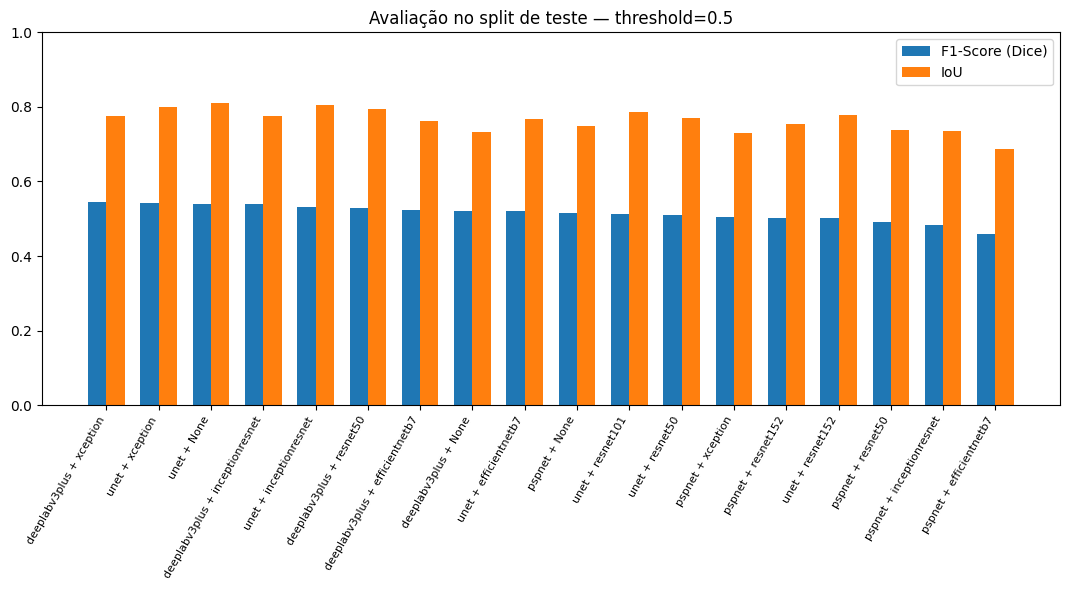

Gráfico salvo em: /content/drive/MyDrive/DL_fotovoltaica/avaliacao_modelos/avaliacao_modelos_teste_20260722_1050.png


In [33]:
## célula 13
df_ok = df_resultados[df_resultados['status'] == 'ok'].copy()
df_ok['combinacao'] = df_ok['segmentation_head'] + ' + ' + df_ok['backbone_name']

fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(df_ok)), 6))
x = np.arange(len(df_ok))
width = 0.35
ax.bar(x - width/2, df_ok['f1_score_dice'], width, label='F1-Score (Dice)')
ax.bar(x + width/2, df_ok['iou'],           width, label='IoU')
ax.set_xticks(x)
ax.set_xticklabels(df_ok['combinacao'], rotation=60, ha='right', fontsize=8)
ax.set_ylim(0, 1)
ax.set_title(f'Avaliação no split de teste — threshold={EVAL_THRESHOLD}')
ax.legend()
plt.tight_layout()

fig_path = os.path.join(RESULTS_DIR, f'avaliacao_modelos_teste_{TIMESTAMP_RUN}.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Gráfico salvo em: {fig_path}')
